# IT3051 – Telco Customer Churn Prediction
## Model Development & Optimization – XGBoost

**Member:** _(add your name / registration number)_
**Model assigned:** XGBoost (Extreme Gradient Boosting) Classifier
**Input data:** `train_processed.csv` / `test_processed.csv` (output of Member 3's preprocessing pipeline)
**Output:** `models/xgboost_final.pkl` + `models/xgboost_final_metadata.json`

This notebook covers the complete development, evaluation, tuning and interpretation of an XGBoost
model for predicting customer churn. It is organised around the two project stages it addresses:

| Project stage | Where it is covered |
|---|---|
| **Stage 6 – Model Development** | §2 validation strategy · §3 no-skill baseline · §4 baseline XGBoost and overfitting diagnosis · §5 class imbalance · §13 experiment log |
| **Stage 7 – Optimization & Final Selection** | §6 two-stage hyperparameter search · §7 baseline vs tuned · §8 threshold tuning · §9–10 feature importance and feature selection/engineering experiments · §11 error analysis · §12 saved final model · §14 final selection |

### Objectives
- Define a validation strategy that keeps the test set untouched until final reporting
- Establish a "no skill" baseline that any useful model must beat
- Train a baseline XGBoost and diagnose over/underfitting (train vs validation, boosting-round curves)
- Test how class imbalance handling (`scale_pos_weight`) changes the precision–recall trade-off
- Tune hyperparameters with a coarse-to-fine search (RandomizedSearchCV → GridSearchCV)
- Compare baseline vs tuned performance on the held-out test set
- Choose the decision threshold on out-of-fold training predictions (not on the test set)
- Investigate whether the engineered features (`Tenure Group`, `Total Services`) and feature selection help
- Explain *why* the tuned XGBoost performs better than its default configuration
- Record every experiment in a single experiment log and save the final model

## 0. Setup

All paths are relative to this notebook's folder (`Notebook/modelCreation/XGBoost/`), so the project
root is three levels up. `RANDOM_STATE` is fixed everywhere so every result in this notebook is reproducible.

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sklearn
import xgboost
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict,
    RandomizedSearchCV, GridSearchCV, train_test_split
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

%matplotlib inline
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
ROOT = "../../../"              # this notebook lives in Notebook/modelCreation/XGBoost/
MODEL_DIR = ROOT + "models/"

print("xgboost     :", xgboost.__version__)
print("scikit-learn:", sklearn.__version__)

xgboost     : 3.2.0
scikit-learn: 1.9.1


## 1. Data Overview and Class Imbalance

The processed data has already been cleaned, feature-selected, one-hot encoded and scaled by the
team's preprocessing pipeline, and split 80/20 with `stratify=y` so both sets keep the same churn ratio.

In [2]:
train_df = pd.read_csv(ROOT + "train_processed.csv")
test_df = pd.read_csv(ROOT + "test_processed.csv")

TARGET = "Churn Label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)
print("Missing values in train/test:", int(X_train.isna().sum().sum()), "/", int(X_test.isna().sum().sum()))

X_train: (5634, 57) | y_train: (5634,)
X_test : (1409, 57) | y_test : (1409,)
Missing values in train/test: 0 / 0


In [3]:
balance = pd.DataFrame({
    "Train count": y_train.value_counts(),
    "Train %": (y_train.value_counts(normalize=True) * 100).round(2),
    "Test count": y_test.value_counts(),
    "Test %": (y_test.value_counts(normalize=True) * 100).round(2),
})
balance.index = ["0 = No churn", "1 = Churn"]
print(balance)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_WEIGHT = neg / pos
print(f"\nNegative/positive ratio in training data: {SCALE_POS_WEIGHT:.3f}")

              Train count  Train %  Test count  Test %
0 = No churn         4139    73.46        1035   73.46
1 = Churn            1495    26.54         374   26.54

Negative/positive ratio in training data: 2.769


The target is imbalanced (about **73% no churn vs 27% churn**), which drives several choices in this notebook:

- **Accuracy alone is misleading** – always predicting "No churn" already scores about 73%.
- The main selection metric is **F1 on the churn class**, supported by **recall** (missed churners are
  costly), **ROC-AUC** (ranking quality across all thresholds) and **PR-AUC / average precision**
  (ranking quality focused on the minority class, more informative than ROC-AUC under imbalance).
- The negative/positive ratio above (≈2.77) is the value XGBoost's `scale_pos_weight` parameter needs
  to give both classes equal total weight – tested in Section 5.

## 2. Validation Strategy

- The **test set (1,409 customers) is held out** and used only to report final performance. Every
  modelling decision – hyperparameters, class weighting, decision threshold, feature set – is made
  using the **training set only**.
- Inside the training set we use **5-fold Stratified Cross-Validation** (`shuffle=True`, fixed seed).
  Stratification keeps the 27% churn rate in every fold; using the *same* folds for every experiment
  makes the comparisons fair (differences come from the model, not from a lucky split).
- For each experiment we record the mean CV score of six metrics, the fold-to-fold standard deviation
  of F1 (stability), and the **training F1**, so the train–validation gap exposes overfitting.

Every experiment is appended to `experiment_log`, which is displayed in full at the end (Section 13).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CV_METRICS = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

experiment_log = []


def evaluate_cv(name, model, X=None, notes=""):
    """5-fold stratified CV on the training set; records the result in experiment_log."""
    X = X_train if X is None else X
    res = cross_validate(model, X, y_train, cv=cv, scoring=CV_METRICS,
                         return_train_score=True, n_jobs=-1)
    row = {"Experiment": name}
    for m in CV_METRICS:
        row[m] = res[f"test_{m}"].mean()
    row["f1_std"] = res["test_f1"].std()
    row["train_f1"] = res["train_f1"].mean()
    row["f1_gap"] = row["train_f1"] - row["f1"]
    row["n_features"] = X.shape[1]
    row["notes"] = notes
    experiment_log.append(row)
    return row


def cv_table(rows):
    cols = ["accuracy", "precision", "recall", "f1", "f1_std", "roc_auc", "pr_auc", "train_f1", "f1_gap"]
    return pd.DataFrame(rows).set_index("Experiment")[cols].round(4)


def test_scores(y_true, y_pred, y_proba):
    """Held-out test metrics for one model."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }

## 3. Baseline Reference – Dummy Classifier

A classifier that always predicts the majority class sets the "no skill" floor. Any useful model must
clearly beat it on F1/recall, not just on accuracy.

In [5]:
dummy = DummyClassifier(strategy="most_frequent")
dummy_cv = evaluate_cv("Dummy (majority class)", dummy, notes="no-skill floor")
cv_table([dummy_cv])

,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap
Experiment,,,,,,,,,
Dummy (majority class),0.7346,0.0,0.0,0.0,0.0,0.5,0.2654,0.0,0.0


As expected the dummy model reaches ~73% accuracy with **zero recall and zero F1** – it never
identifies a single churner. Its ROC-AUC of 0.5 and PR-AUC of ~0.27 (the churn rate) are the
random-ranking floor for those metrics.

## 4. Baseline XGBoost and Overfitting Diagnosis

### Why XGBoost suits this problem

XGBoost (Extreme Gradient Boosting) builds an ensemble of small decision trees **sequentially**: each new
tree is fitted to the errors (gradients of the loss) that the trees built so far still make, and its
contribution is shrunk by the `learning_rate`. This makes it well suited to churn prediction on tabular data:

- **Non-linear effects and interactions** (e.g. the U-shaped `Total Services` effect, or contract type
  interacting with tenure) are captured automatically by the trees – no manual interaction terms needed.
- **Mixed feature types** (scaled numeric + one-hot categorical) are handled natively; tree splits are not
  affected by feature scale.
- **Built-in regularisation** (`gamma`, `min_child_weight`, `reg_lambda`, `reg_alpha`, row/column
  subsampling, shrinkage) gives direct control over overfitting on a dataset of this size (~5.6k rows).
- **Class imbalance** can be handled directly with `scale_pos_weight` (Section 5).
- It outputs **smooth probabilities** (a sum of many trees), which gives fine-grained risk rankings and
  allows the decision threshold to be tuned (Section 8).

The main weakness is its many hyperparameters – the defaults are rarely optimal for a small dataset, which
is why this notebook tunes it systematically.

### Baseline model

The default XGBoost uses 100 trees, `max_depth=6`, `learning_rate=0.3`, no row/column subsampling and
light L2 regularisation (`reg_lambda=1`). We evaluate it with the same CV folds as the dummy baseline,
then look at overfitting from two angles:

1. **Train vs validation F1** from cross-validation (the `f1_gap` column).
2. **Boosting-round curves** – how training and validation log-loss evolve as trees are added. We carve a
   stratified 20% validation slice out of the *training* set for this (the test set is still untouched).

In [6]:
xgb_baseline = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1)
baseline_row = evaluate_cv("XGBoost (default)", xgb_baseline, notes="baseline, default hyperparameters")

print(f"Baseline XGBoost  - train F1: {baseline_row['train_f1']:.4f} | CV F1: {baseline_row['f1']:.4f} "
      f"| gap: {baseline_row['f1_gap']:.4f}")
print(f"                    CV ROC-AUC: {baseline_row['roc_auc']:.4f} | CV PR-AUC: {baseline_row['pr_auc']:.4f}")
cv_table([dummy_cv, baseline_row])

Baseline XGBoost  - train F1: 0.9941 | CV F1: 0.6642 | gap: 0.3298
                    CV ROC-AUC: 0.8890 | CV PR-AUC: 0.7435


,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap
Experiment,,,,,,,,,
Dummy (majority class),0.7346,0.0000,0.0000,0.0000,0.0000,0.500,0.2654,0.0000,0.0000
XGBoost (default),0.8317,0.7065,0.6274,0.6642,0.0117,0.889,0.7435,0.9941,0.3298


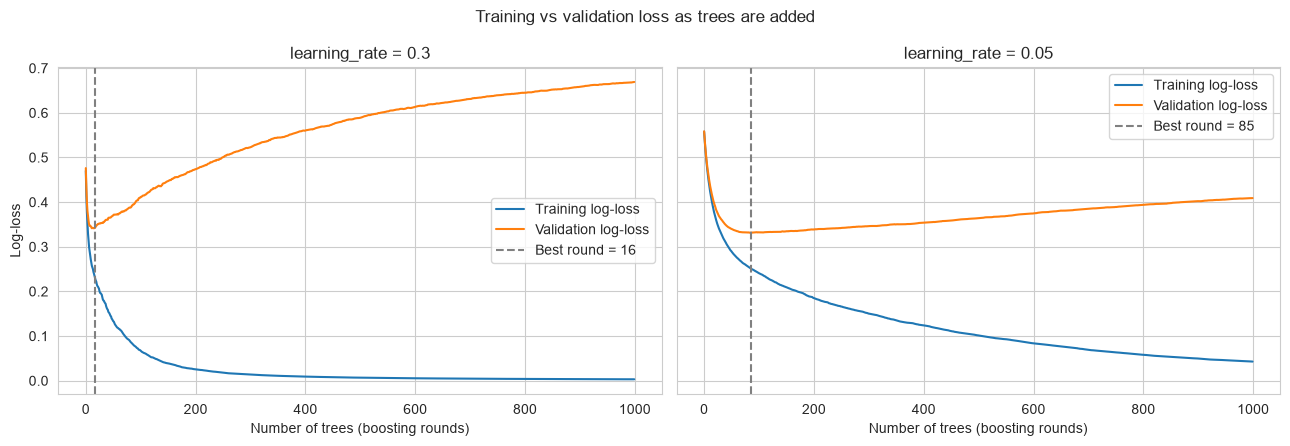

,best_round,min_val_logloss,val_logloss_at_100,val_logloss_at_1000,train_logloss_at_1000
learning_rate,,,,,
0.30,16,0.3413,0.4105,0.6691,0.0031
0.05,85,0.3313,0.3323,0.4089,0.0428


In [7]:
X_sub, X_val, y_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.20, stratify=y_train, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
round_summary = []
for ax, lr in zip(axes, [0.3, 0.05]):
    m = XGBClassifier(n_estimators=1000, learning_rate=lr, eval_metric="logloss",
                      random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_sub, y_sub, eval_set=[(X_sub, y_sub), (X_val, y_val)], verbose=False)
    ev = m.evals_result()
    train_loss, val_loss = ev["validation_0"]["logloss"], ev["validation_1"]["logloss"]
    best_round = int(np.argmin(val_loss)) + 1

    ax.plot(train_loss, label="Training log-loss")
    ax.plot(val_loss, label="Validation log-loss")
    ax.axvline(best_round, color="gray", linestyle="--", label=f"Best round = {best_round}")
    ax.set_title(f"learning_rate = {lr}")
    ax.set_xlabel("Number of trees (boosting rounds)")
    ax.legend()
    round_summary.append({
        "learning_rate": lr,
        "best_round": best_round,
        "min_val_logloss": min(val_loss),
        "val_logloss_at_100": val_loss[99],
        "val_logloss_at_1000": val_loss[-1],
        "train_logloss_at_1000": train_loss[-1],
    })
axes[0].set_ylabel("Log-loss")
plt.suptitle("Training vs validation loss as trees are added")
plt.tight_layout()
plt.show()

pd.DataFrame(round_summary).set_index("learning_rate").round(4)

### Interpretation – Baseline and Overfitting Diagnosis

- **The baseline clearly learns real churn patterns.** Compared with the dummy model it reaches CV F1 0.664
  (vs 0), ROC-AUC 0.889 (vs 0.5) and PR-AUC 0.744 (vs 0.265). Its recall of 0.627, however, means more
  than a third of churners are still missed.
- **The baseline overfits, it does not underfit.** Training F1 is 0.994 while cross-validated F1 is 0.664 –
  a gap of 0.33. The model has enough capacity; the problem is too much variance.
- **Boosting-round curves show exactly when it happens.** With the default `learning_rate=0.3`, validation
  log-loss is lowest after only **16 trees** (0.341). By 100 trees (the default) it has already risen to
  0.411, and by 1,000 trees to 0.669, while training loss falls to almost zero (0.003). Every tree added
  after ~16 fits noise in the training data rather than real patterns.
- **A smaller learning rate helps.** With `learning_rate=0.05` each tree contributes less, so the optimum
  is reached later (85 trees), is **lower** (0.331) and the curve rises much more slowly afterwards
  (0.409 at 1,000 trees). The model becomes less sensitive to the exact number of trees.

**Consequence for tuning:** `n_estimators` and `learning_rate` must be tuned *together*, and the
regularisation parameters (`max_depth`, `min_child_weight`, `gamma`, `subsample`, `colsample_bytree`,
`reg_lambda`, `reg_alpha`) are needed to close the train–validation gap.

## 5. Handling Class Imbalance – `scale_pos_weight`

XGBoost handles imbalance with `scale_pos_weight`, which multiplies the gradient of every positive
(churn) example. Setting it to the negative/positive ratio (≈2.77) gives both classes equal total weight;
the square root (≈1.66) is a common softer compromise.

**Why re-weighting instead of resampling (e.g. SMOTE)?** Re-weighting uses only real customers,
adds no synthetic rows, and needs no extra step inside each CV fold (oversampling *before* splitting
would leak copies of validation rows into training). We compare the three settings on the default model.

In [8]:
# scale_pos_weight = 1 is exactly the default XGBoost already evaluated in Section 4
imbalance_rows = [baseline_row]
for label, spw in [("sqrt ratio", np.sqrt(SCALE_POS_WEIGHT)),
                   ("full neg/pos ratio", SCALE_POS_WEIGHT)]:
    model = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1,
                          scale_pos_weight=spw)
    imbalance_rows.append(evaluate_cv(f"XGBoost default, scale_pos_weight={label}", model,
                                      notes=f"imbalance: spw={spw:.2f}"))

cv_table(imbalance_rows)

,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap
Experiment,,,,,,,,,
XGBoost (default),0.8317,0.7065,0.6274,0.6642,0.0117,0.8890,0.7435,0.9941,0.3298
"XGBoost default, scale_pos_weight=sqrt ratio",0.8291,0.6818,0.6696,0.6755,0.0235,0.8879,0.7508,0.9945,0.3190
"XGBoost default, scale_pos_weight=full neg/pos ratio",0.8264,0.6644,0.7003,0.6817,0.0120,0.8874,0.7443,0.9871,0.3053


### Interpretation – Effect of `scale_pos_weight`

(The first row is the default XGBoost from Section 4, which uses `scale_pos_weight=1`.)

- Increasing the weight of churners pushes predictions towards "churn": **recall rises 0.627 → 0.670 →
  0.700** while **precision falls 0.707 → 0.682 → 0.664**.
- **F1 improves 0.664 → 0.676 → 0.682**, because the recall gained outweighs the precision lost.
- **ROC-AUC and PR-AUC barely move** (0.887–0.889 and 0.744–0.751). Re-weighting does not make the model
  better at *ranking* customers by risk; it mainly changes where the 0.5 cut-off falls in that ranking.
  It is closely related to moving the decision threshold, which is examined separately in Section 8.
- The best amount of re-weighting depends on the other hyperparameters (a heavily regularised model
  behaves differently from this overfitting default), so `scale_pos_weight` is included in the
  hyperparameter search (1, √ratio, ratio) rather than fixed here.

## 6. Hyperparameter Tuning – Coarse-to-Fine Search

XGBoost has many interacting hyperparameters, so an exhaustive grid over all of them would need
tens of thousands of fits. We use a **two-stage strategy**:

1. **Stage 1 – RandomizedSearchCV (broad):** 60 random combinations sampled from wide distributions.
   Random search covers a large space far more efficiently than a grid, because only a few
   hyperparameters usually matter and random sampling tries many distinct values of each.
2. **Stage 2 – GridSearchCV (fine):** a small exhaustive grid *around* the best Stage 1 result for the
   three most influential parameters (`max_depth`, `learning_rate`, `n_estimators`).

| Hyperparameter | What it controls | Search range |
|---|---|---|
| `n_estimators` | Number of trees | 100 – 800 |
| `learning_rate` | Shrinkage of each tree's contribution (lower = slower, more robust learning) | 0.01 – 0.3 (log scale) |
| `max_depth` | Depth of each tree → complexity of interactions | 2 – 8 |
| `min_child_weight` | Minimum weight in a leaf → blocks splits on tiny groups | 1 – 10 |
| `subsample` | Fraction of rows used per tree (row bagging) | 0.6 – 1.0 |
| `colsample_bytree` | Fraction of features used per tree | 0.4 – 1.0 |
| `gamma` | Minimum loss reduction required to split (pruning) | 0 – 5 |
| `reg_lambda`, `reg_alpha` | L2 / L1 penalty on leaf weights | 0.1 – 20 / 0.001 – 5 (log) |
| `scale_pos_weight` | Class re-weighting (Section 5) | 1, √ratio, ratio |

Both stages optimise **F1** (the main metric chosen in Section 1), scored with the same 5 folds.
ROC-AUC and PR-AUC are recorded for every candidate too.

In [9]:
param_dist = {
    "n_estimators": randint(100, 801),
    "learning_rate": loguniform(0.01, 0.3),
    "max_depth": randint(2, 9),
    "min_child_weight": randint(1, 11),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.4, 0.6),
    "gamma": uniform(0, 5),
    "reg_lambda": loguniform(0.1, 20),
    "reg_alpha": loguniform(0.001, 5),
    "scale_pos_weight": [1.0, float(np.sqrt(SCALE_POS_WEIGHT)), float(SCALE_POS_WEIGHT)],
}

SEARCH_SCORING = {"f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_dist,
    n_iter=60,
    scoring=SEARCH_SCORING,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=True,
    verbose=1,
)
random_search.fit(X_train, y_train)

print("Best Stage 1 CV F1:", round(random_search.best_score_, 4))
pd.Series(random_search.best_params_).round(4)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


Best Stage 1 CV F1: 0.7169


colsample_bytree      0.8877
gamma                 4.7362
learning_rate         0.2861
max_depth             5.0000
min_child_weight      4.0000
n_estimators        169.0000
reg_alpha             0.4164
reg_lambda            1.2833
scale_pos_weight      1.6639
subsample             0.8820
dtype: float64

In [10]:
rs_results = pd.DataFrame(random_search.cv_results_)
param_cols = [c for c in rs_results.columns if c.startswith("param_")]
top10 = (rs_results
         .sort_values("rank_test_f1")
         .loc[:, param_cols + ["mean_train_f1", "mean_test_f1", "mean_test_roc_auc", "mean_test_pr_auc"]]
         .head(10))
top10.columns = [c.replace("param_", "") for c in top10.columns]
top10.astype(float).round(3)

,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,scale_pos_weight,subsample,mean_train_f1,mean_test_f1,mean_test_roc_auc,mean_test_pr_auc
51,0.888,4.736,0.286,5.0,4.0,169.0,0.416,1.283,1.664,0.882,0.772,0.717,0.905,0.782
2,0.767,0.035,0.011,4.0,10.0,575.0,3.998,0.343,1.664,0.914,0.747,0.717,0.908,0.790
5,0.509,3.777,0.042,7.0,10.0,576.0,3.859,6.076,1.664,0.758,0.746,0.716,0.907,0.789
12,0.763,2.699,0.020,6.0,7.0,798.0,0.372,10.617,1.664,0.923,0.776,0.716,0.908,0.788
18,0.803,3.808,0.022,8.0,6.0,379.0,0.055,18.318,1.664,0.814,0.759,0.715,0.908,0.787
19,0.454,4.177,0.030,7.0,3.0,759.0,0.016,0.321,1.664,0.805,0.794,0.715,0.909,0.792
4,0.885,1.523,0.014,5.0,7.0,527.0,0.068,0.120,1.664,0.756,0.794,0.714,0.908,0.789
53,0.847,3.405,0.022,2.0,1.0,508.0,1.633,0.327,1.664,0.921,0.728,0.713,0.905,0.783
10,0.783,4.436,0.050,6.0,3.0,104.0,0.119,5.943,2.769,0.616,0.762,0.712,0.908,0.788
54,0.987,2.780,0.030,7.0,5.0,302.0,2.511,0.382,2.769,0.988,0.799,0.712,0.907,0.786


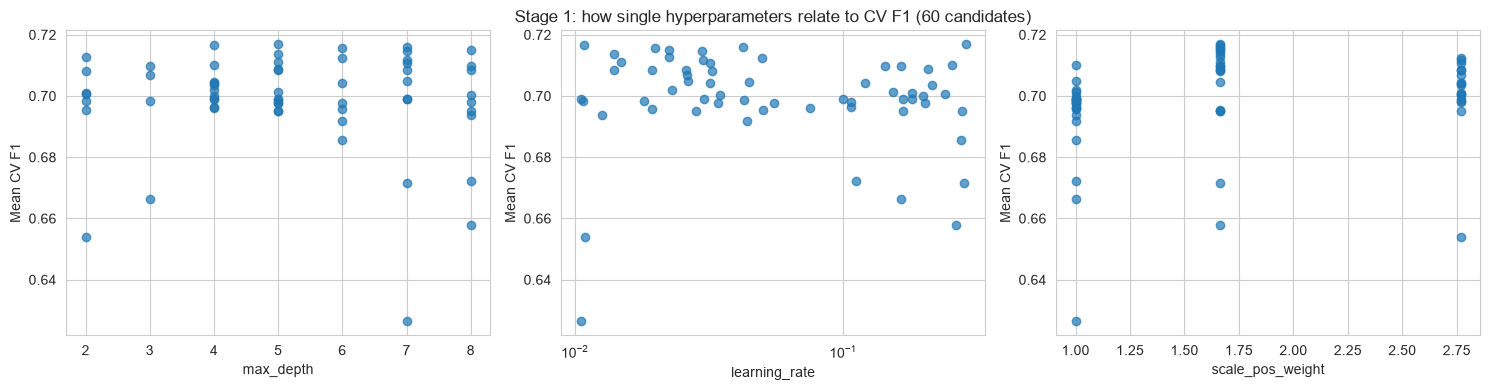

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, p in zip(axes, ["param_max_depth", "param_learning_rate", "param_scale_pos_weight"]):
    ax.scatter(rs_results[p].astype(float), rs_results["mean_test_f1"], alpha=0.7)
    ax.set_xlabel(p.replace("param_", ""))
    ax.set_ylabel("Mean CV F1")
    if p == "param_learning_rate":
        ax.set_xscale("log")
axes[1].set_title("Stage 1: how single hyperparameters relate to CV F1 (60 candidates)")
plt.tight_layout()
plt.show()

### Interpretation – Stage 1 (Random Search)

- The best candidate reaches **CV F1 0.717** (vs 0.664 for the default) with `learning_rate≈0.29`,
  `max_depth=5`, `min_child_weight=4`, `gamma≈4.7`, 169 trees and `scale_pos_weight=√ratio (1.66)`.
  The high learning rate is balanced by a large `gamma`: a split is only made if it reduces the loss by at
  least 4.7, which prunes weak splits aggressively, so few trees are needed.
- **The optimum is a broad plateau.** The ten best candidates are all within 0.005 F1 of each other
  (0.712–0.717, ROC-AUC 0.905–0.909) despite very different settings – learning rates from 0.011 to 0.29,
  104 to 798 trees, depth 2 to 8. What they share is strong regularisation: their training F1 is
  0.73–0.80 instead of the default's 0.99. The scatter plots confirm this: no single value of `max_depth`
  or `learning_rate` guarantees a good score – it is the *combination* that matters.
- **Moderate re-weighting wins.** 8 of the top 10 candidates use `scale_pos_weight = √ratio`, and in the
  right-hand plot that value forms the highest cluster. No re-weighting misses too many churners; the full
  ratio creates too many false alarms once the model is regularised.

Stage 2 now refines the three most influential parameters around this point.

In [12]:
best1 = random_search.best_params_
lr1, n1, d1 = float(best1["learning_rate"]), int(best1["n_estimators"]), int(best1["max_depth"])

fine_grid = {
    "max_depth": sorted({max(2, d1 - 1), d1, d1 + 1}),
    "learning_rate": sorted({round(lr1 * 0.5, 5), round(lr1, 5), round(lr1 * 1.5, 5)}),
    "n_estimators": sorted({max(50, int(n1 * 0.6)), n1, int(n1 * 1.4)}),
}
fixed_params = {k: (int(v) if isinstance(v, (int, np.integer)) else float(v))
                for k, v in best1.items() if k not in fine_grid}
print("Fine grid:", fine_grid)
print("Fixed from Stage 1:", {k: round(v, 4) if isinstance(v, float) else v for k, v in fixed_params.items()})

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1, **fixed_params),
    param_grid=fine_grid,
    scoring=SEARCH_SCORING,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("\nBest Stage 2 CV F1:", round(grid_search.best_score_, 4), "| params:",
      {k: (round(float(v), 5) if isinstance(v, float) else v) for k, v in grid_search.best_params_.items()})

Fine grid: {'max_depth': [4, 5, 6], 'learning_rate': [0.14303, 0.28605, 0.42908], 'n_estimators': [101, 169, 236]}
Fixed from Stage 1: {'colsample_bytree': 0.8877, 'gamma': 4.7362, 'min_child_weight': 4, 'reg_alpha': 0.4164, 'reg_lambda': 1.2833, 'scale_pos_weight': 1.6639, 'subsample': 0.882}
Fitting 5 folds for each of 27 candidates, totalling 135 fits



Best Stage 2 CV F1: 0.7196 | params: {'learning_rate': 0.14303, 'max_depth': 5, 'n_estimators': 169}


In [13]:
# Pick whichever stage produced the better cross-validated F1
if grid_search.best_score_ >= random_search.best_score_:
    tuned_params = {**fixed_params, **grid_search.best_params_}
    chosen_stage = "Stage 2 (grid refinement)"
else:
    tuned_params = dict(best1)
    chosen_stage = "Stage 1 (random search)"
print("Chosen:", chosen_stage)

xgb_tuned = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1, **tuned_params)
tuned_row = evaluate_cv("XGBoost tuned (all features)", clone(xgb_tuned).set_params(n_jobs=1),
                        notes=f"{chosen_stage}")
xgb_tuned.fit(X_train, y_train)

cv_table([baseline_row, tuned_row])

Chosen: Stage 2 (grid refinement)


,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap
Experiment,,,,,,,,,
XGBoost (default),0.8317,0.7065,0.6274,0.6642,0.0117,0.8890,0.7435,0.9941,0.3298
XGBoost tuned (all features),0.8422,0.6810,0.7632,0.7196,0.0185,0.9075,0.7859,0.7706,0.0509


In [14]:
pd.Series({k: (round(float(v), 4) if isinstance(v, float) else v) for k, v in tuned_params.items()},
          name="Final tuned hyperparameters", dtype=object).to_frame()

,Final tuned hyperparameters
colsample_bytree,0.8877
gamma,4.7362
min_child_weight,4
reg_alpha,0.4164
reg_lambda,1.2833
scale_pos_weight,1.6639
subsample,0.882
learning_rate,0.143
max_depth,5
n_estimators,169


### Interpretation – Tuned vs Baseline (Cross-Validation)

- **Stage 2 halved the learning rate** (0.286 → 0.143) with the same depth (5) and number of trees (169),
  improving CV F1 slightly from 0.717 to **0.720**. A small gain is expected: Stage 1 had already found
  the plateau, and Stage 2 confirms that we are at (or very near) its top rather than on a lucky outlier.
- **Compared with the default XGBoost:** CV F1 0.664 → **0.720** (+0.055), recall 0.627 → **0.763**,
  ROC-AUC 0.889 → **0.908**, PR-AUC 0.744 → **0.786**. Both the classification at 0.5 and the ranking
  quality improved.
- **Most importantly, overfitting is under control:** training F1 dropped from 0.994 to 0.771 and the
  train–validation gap shrank from **0.330 to 0.051**. The model now learns patterns that generalise
  instead of memorising training customers. The regularisers doing this work are `gamma≈4.7` (split
  pruning), `min_child_weight=4`, depth 5, and row/column subsampling (≈0.88/0.89).
- The fold-to-fold standard deviation of F1 (0.019) is small, so the improvement is stable across folds.

## 7. Baseline vs Tuned – Held-out Test Set

Now, for the first time, the test set is used: the baseline and the tuned model are both trained on the
full training set and evaluated once on the 1,409 unseen customers (default 0.5 threshold).

In [15]:
xgb_baseline.set_params(n_jobs=-1).fit(X_train, y_train)

proba_base = xgb_baseline.predict_proba(X_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)
proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]
pred_tuned = (proba_tuned >= 0.5).astype(int)

test_comparison = pd.DataFrame({
    "Baseline XGBoost (default)": test_scores(y_test, pred_base, proba_base),
    "Tuned XGBoost (threshold 0.5)": test_scores(y_test, pred_tuned, proba_tuned),
})
test_comparison["Change"] = test_comparison.iloc[:, 1] - test_comparison.iloc[:, 0]
test_comparison.round(4)

,Baseline XGBoost (default),Tuned XGBoost (threshold 0.5),Change
Accuracy,0.8403,0.8453,0.0050
Precision,0.7198,0.6857,-0.0340
Recall,0.6524,0.7701,0.1176
F1,0.6844,0.7254,0.0410
ROC-AUC,0.9037,0.9142,0.0105
PR-AUC,0.7574,0.7887,0.0313


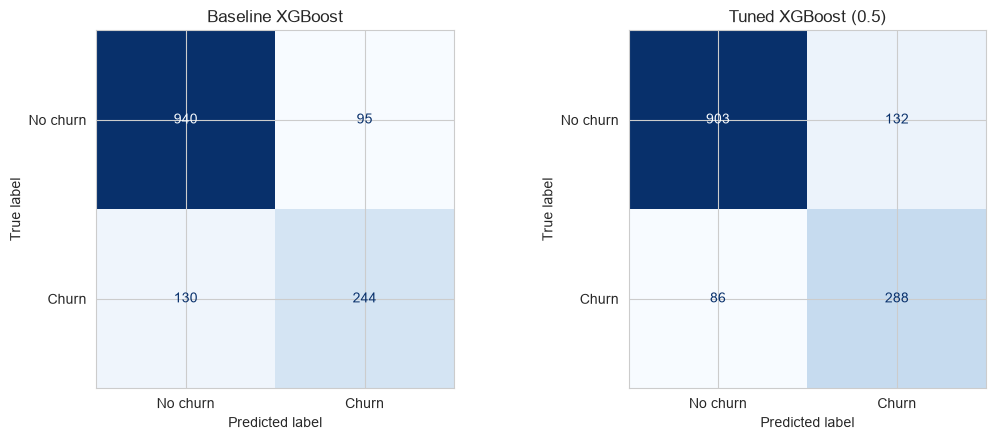

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, pred) in zip(axes, [("Baseline XGBoost", pred_base), ("Tuned XGBoost (0.5)", pred_tuned)]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["No churn", "Churn"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

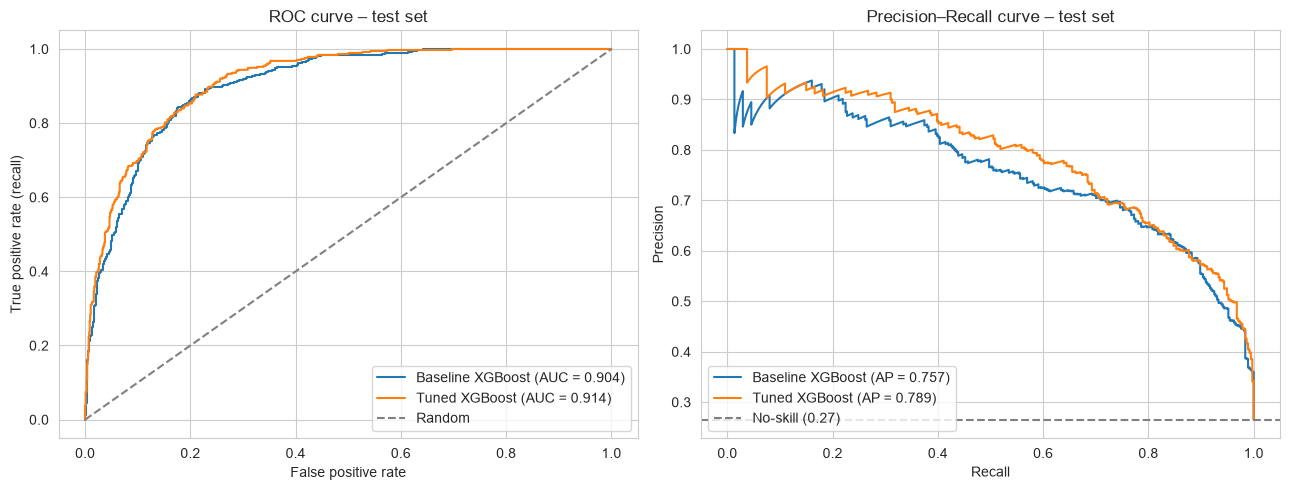

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, proba in [("Baseline XGBoost", proba_base), ("Tuned XGBoost", proba_tuned)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curve – test set")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"No-skill ({y_test.mean():.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall curve – test set")
axes[0].legend(loc="lower right")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

### Interpretation – Baseline vs Tuned on the Test Set

- **The test set confirms the cross-validation results.** Tuning raised F1 from 0.684 to **0.725** (+0.041)
  and recall from 0.652 to **0.770** (+0.118) – about **44 more of the 374 real churners are caught**. The
  price is a small drop in precision (0.720 → 0.686), i.e. a few more false alarms.
- **Ranking quality improved too:** ROC-AUC 0.904 → **0.914** and PR-AUC 0.757 → **0.789**. These metrics do
  not depend on the threshold, so the gain is not just a side effect of re-weighting – the tuned model
  genuinely separates churners from non-churners better.
- **Test scores are close to the CV estimates** (F1 0.725 vs 0.720, ROC-AUC 0.914 vs 0.908), which shows the
  cross-validated search did not overfit the validation folds and that CV was a reliable guide.

## 8. Decision Threshold Tuning (on Out-of-Fold Training Predictions)

`predict()` labels a customer as a churner when the predicted probability is ≥ 0.5, but 0.5 is
arbitrary. To choose a better cut-off **without touching the test set**, we generate
**out-of-fold (OOF) probabilities** for every training customer with `cross_val_predict` – each customer
is scored by a model that never saw them – and pick the threshold that maximises F1 on those. The
chosen threshold is then applied to the test set exactly once.

(Choosing the threshold on the test set itself would make the reported test F1 optimistically biased.)

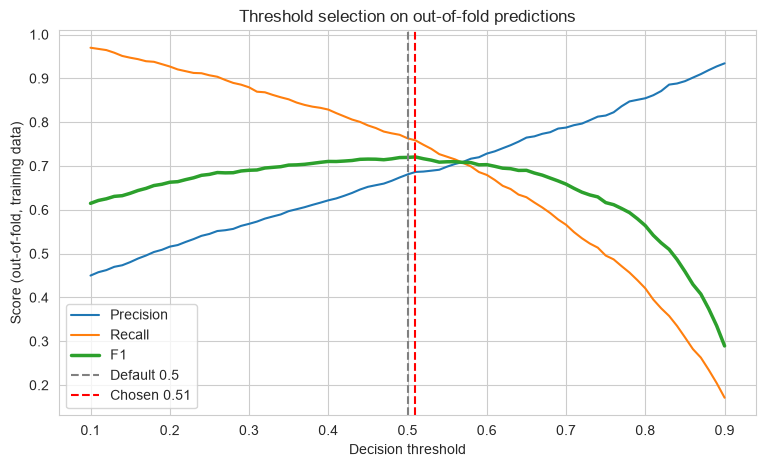

OOF F1 at 0.50: 0.7196
OOF F1 at 0.51: 0.7207  <- chosen threshold


,precision,recall,f1
threshold,,,
0.30,0.5680,0.8796,0.6903
0.40,0.6217,0.8288,0.7104
0.50,0.6808,0.7632,0.7196
0.51,0.6864,0.7585,0.7207
0.60,0.7283,0.6796,0.7031
0.70,0.7877,0.5659,0.6586


In [18]:
oof_proba = cross_val_predict(clone(xgb_tuned).set_params(n_jobs=1), X_train, y_train,
                              cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.round(np.arange(0.10, 0.91, 0.01), 2)
oof_curve = pd.DataFrame({
    "threshold": thresholds,
    "precision": [precision_score(y_train, oof_proba >= t, zero_division=0) for t in thresholds],
    "recall": [recall_score(y_train, oof_proba >= t) for t in thresholds],
    "f1": [f1_score(y_train, oof_proba >= t) for t in thresholds],
})

best_idx = oof_curve["f1"].idxmax()
BEST_THRESHOLD = float(oof_curve.loc[best_idx, "threshold"])

plt.figure(figsize=(9, 5))
plt.plot(oof_curve["threshold"], oof_curve["precision"], label="Precision")
plt.plot(oof_curve["threshold"], oof_curve["recall"], label="Recall")
plt.plot(oof_curve["threshold"], oof_curve["f1"], label="F1", linewidth=2.5)
plt.axvline(0.5, linestyle="--", color="gray", label="Default 0.5")
plt.axvline(BEST_THRESHOLD, linestyle="--", color="red", label=f"Chosen {BEST_THRESHOLD:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score (out-of-fold, training data)")
plt.title("Threshold selection on out-of-fold predictions")
plt.legend()
plt.show()

print(f"OOF F1 at 0.50: {oof_curve.loc[oof_curve.threshold == 0.5, 'f1'].item():.4f}")
print(f"OOF F1 at {BEST_THRESHOLD:.2f}: {oof_curve.loc[best_idx, 'f1']:.4f}  <- chosen threshold")

# The trade-off the business can choose from (out-of-fold, training data)
oof_curve.set_index("threshold").loc[sorted({0.3, 0.4, 0.5, BEST_THRESHOLD, 0.6, 0.7})].round(4)

In [19]:
pred_tuned_t = (proba_tuned >= BEST_THRESHOLD).astype(int)

test_comparison[f"Tuned XGBoost (threshold {BEST_THRESHOLD:.2f})"] = pd.Series(
    test_scores(y_test, pred_tuned_t, proba_tuned))
test_comparison.drop(columns="Change").round(4)

,Baseline XGBoost (default),Tuned XGBoost (threshold 0.5),Tuned XGBoost (threshold 0.51)
Accuracy,0.8403,0.8453,0.8432
Precision,0.7198,0.6857,0.6835
Recall,0.6524,0.7701,0.7620
F1,0.6844,0.7254,0.7206
ROC-AUC,0.9037,0.9142,0.9142
PR-AUC,0.7574,0.7887,0.7887


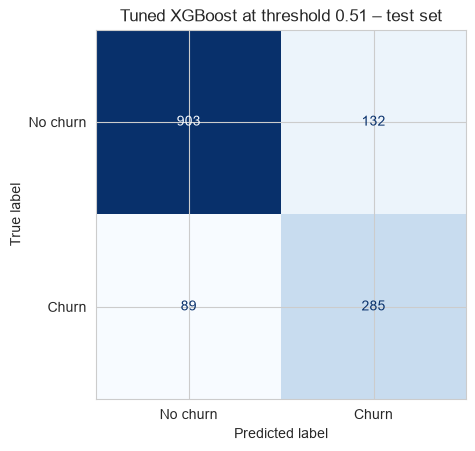

In [20]:
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tuned_t), display_labels=["No churn", "Churn"]).plot(
    cmap="Blues", colorbar=False)
plt.title(f"Tuned XGBoost at threshold {BEST_THRESHOLD:.2f} – test set")
plt.show()

### Interpretation – Threshold Tuning

- **The F1 curve is flat around 0.5.** The best out-of-fold threshold is **0.51** (OOF F1 0.7207 vs 0.7196 at
  0.50, a gain of only 0.001). This is because `scale_pos_weight = √ratio` was already chosen during tuning
  to balance precision and recall, so the default cut-off is already near-optimal.
- **On the test set, 0.51 gives F1 0.7206 vs 0.7254 at 0.50** – a difference of about 2–3 customers, i.e.
  noise. We still report 0.51 as the final threshold because it was chosen by the procedure fixed in
  advance on training data only. Switching to 0.50 *because* it scores better on the test set would be
  selecting on the test set, which is exactly the optimistic bias this section is designed to avoid.
- **Practical value:** the table above shows the trade-off the business can pick from. Lowering the
  threshold to 0.40 raises recall from 0.76 to 0.83 while F1 falls only slightly (0.720 → 0.710), because
  precision drops from 0.69 to 0.62. Going further to 0.30 catches 88% of churners, but precision falls to
  0.57 (F1 0.690). A lower threshold is a reasonable choice if retention offers are cheap.

## 9. Feature Importance – What Drives the Predictions?

Two complementary views:

- **Gain importance** (built into XGBoost): the average improvement in the loss brought by splits on a
  feature. Fast, but can favour features with many split points.
- **Permutation importance** (model-agnostic): how much test ROC-AUC drops when a feature's values are
  randomly shuffled. It measures what the model actually *relies on* for unseen data.

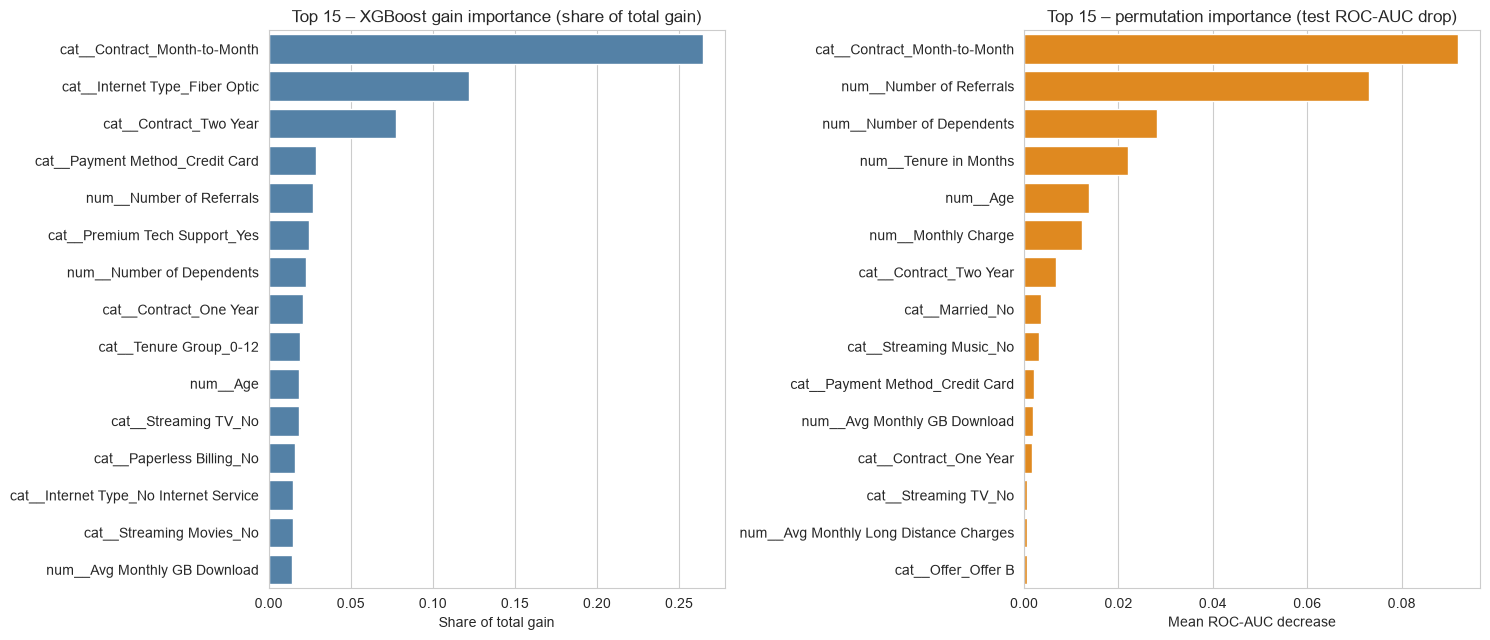

,gain_share,perm_auc_drop,gain_rank,perm_rank
cat__Contract_Month-to-Month,0.2645,0.0920,1,1
num__Number of Referrals,0.0270,0.0731,5,2
num__Number of Dependents,0.0229,0.0281,7,3
num__Tenure in Months,0.0139,0.0220,16,4
num__Age,0.0185,0.0137,10,5
num__Monthly Charge,0.0139,0.0122,17,6
cat__Contract_Two Year,0.0778,0.0067,3,7
cat__Married_No,0.0125,0.0037,22,8
cat__Streaming Music_No,0.0108,0.0031,25,9
cat__Payment Method_Credit Card,0.0288,0.0021,4,10


In [21]:
gain_imp = pd.Series(xgb_tuned.get_booster().get_score(importance_type="gain")).reindex(X_train.columns).fillna(0)
gain_imp = (gain_imp / gain_imp.sum()).sort_values(ascending=False)

perm = permutation_importance(xgb_tuned, X_test, y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
sns.barplot(x=gain_imp.head(15).values, y=gain_imp.head(15).index, ax=axes[0], color="steelblue")
axes[0].set(title="Top 15 – XGBoost gain importance (share of total gain)", xlabel="Share of total gain", ylabel="")
sns.barplot(x=perm_imp.head(15).values, y=perm_imp.head(15).index, ax=axes[1], color="darkorange")
axes[1].set(title="Top 15 – permutation importance (test ROC-AUC drop)", xlabel="Mean ROC-AUC decrease", ylabel="")
plt.tight_layout()
plt.show()

importance_table = pd.DataFrame({"gain_share": gain_imp, "perm_auc_drop": perm_imp})
importance_table["gain_rank"] = importance_table["gain_share"].rank(ascending=False).astype(int)
importance_table["perm_rank"] = importance_table["perm_auc_drop"].rank(ascending=False).astype(int)
importance_table.sort_values("perm_rank").head(15).round(4)

In [22]:
engineered = ["num__Total Services"] + [c for c in X_train.columns if "Tenure Group" in c]
importance_table.loc[engineered].round(4)

,gain_share,perm_auc_drop,gain_rank,perm_rank
num__Total Services,0.0073,-0.0004,34,57
cat__Tenure Group_0-12,0.0189,-0.0001,9,47
cat__Tenure Group_13-24,0.0000,0.0000,53,39
cat__Tenure Group_25-48,0.0000,0.0000,53,39
cat__Tenure Group_49-72,0.0073,0.0002,35,24


### Interpretation – Feature Importance

- **Both methods agree on the dominant driver: `Contract_Month-to-Month`** (26% of total gain; shuffling it
  lowers test ROC-AUC by 0.092). Customers without a long-term commitment are by far the most likely
  to leave.
- **Permutation importance ranks next** `Number of Referrals` (0.073), `Number of Dependents` (0.028),
  `Tenure in Months` (0.022), `Age` (0.014) and `Monthly Charge` (0.012): customers who refer others, have
  dependents and have stayed longer are less likely to churn, while higher charges increase the risk.
- **Where the methods disagree, and why:**
  - `Internet Type_Fiber Optic` (gain rank 2), `Contract_Two Year` (3) and `Payment Method_Credit Card` (4)
    have high gain but little permutation importance. They are correlated with other features (e.g. the
    contract dummies with each other), so when one is shuffled the model can recover the same
    information from the others – permutation importance measures what the model *cannot* do without.
  - `Tenure in Months` and `Monthly Charge` have low gain (ranks 16–17) but high permutation importance.
    XGBoost's "gain" is the *average* gain per split; continuous features are split many times with small
    gains each, which lowers their average even though together those splits matter a lot.
- **Engineered features:** the four `Tenure Group` columns have essentially zero permutation importance
  (two bins are never used at all), and `Total Services` ranks 34th by gain with no permutation importance.
  The tuned model barely relies on them – Section 10 tests whether removing them changes performance.

## 10. Do Feature Engineering / Feature Selection Choices Improve Performance?

Stage 7 asks whether feature selection/engineering choices actually help. Using the tuned
hyperparameters and the same CV folds, we test:

| Experiment | Question |
|---|---|
| Remove `Tenure Group` (4 columns) | Does the engineered tenure binning add anything beyond raw `Tenure in Months`? |
| Remove `Total Services` | Does the engineered service-count feature help? |
| Remove both engineered features | Combined effect of the team's feature engineering |
| Remove redundant binary one-hot complements | One-hot encoding keeps both `X_Yes` and `X_No`; for a two-level variable one column is a perfect mirror of the other |
| Keep only top-*k* features (k = 10, 20, 30) | Does a smaller feature set generalise better? |

For the top-*k* experiments the selection is done **inside each CV fold** with `SelectFromModel` in a
`Pipeline` – ranking features on the whole training set first would leak validation information into
the selection step.

In [23]:
tenure_group_cols = [c for c in X_train.columns if "Tenure Group" in c]
total_services_cols = ["num__Total Services"]

# Two-level one-hot variables (e.g. cat__Married_No / cat__Married_Yes): the second column is redundant
cat_groups = pd.Series([c for c in X_train.columns if c.startswith("cat__")])
cat_groups = cat_groups.groupby(cat_groups.str.rsplit("_", n=1).str[0]).apply(list)
redundant_cols = [cols[0] for cols in cat_groups if len(cols) == 2]
print("Redundant binary complement columns:", len(redundant_cols))
print(redundant_cols)

Redundant binary complement columns: 13
['cat__Device Protection Plan_No', 'cat__Gender_Female', 'cat__Married_No', 'cat__Multiple Lines_No', 'cat__Online Backup_No', 'cat__Online Security_No', 'cat__Paperless Billing_No', 'cat__Phone Service_No', 'cat__Premium Tech Support_No', 'cat__Streaming Movies_No', 'cat__Streaming Music_No', 'cat__Streaming TV_No', 'cat__Unlimited Data_No']


In [24]:
base_estimator = clone(xgb_tuned).set_params(n_jobs=1)

feature_rows = [tuned_row]
for name, drop_cols in [
    ("Tuned – without Tenure Group", tenure_group_cols),
    ("Tuned – without Total Services", total_services_cols),
    ("Tuned – without both engineered features", tenure_group_cols + total_services_cols),
    ("Tuned – without redundant binary complements", redundant_cols),
]:
    feature_rows.append(evaluate_cv(name, base_estimator, X=X_train.drop(columns=drop_cols),
                                    notes=f"feature experiment: drop {len(drop_cols)} cols"))

for k in [10, 20, 30]:
    selector = SelectFromModel(
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
        max_features=k, threshold=-np.inf)
    pipe = Pipeline([("select", selector), ("model", base_estimator)])
    row = evaluate_cv(f"Tuned – top {k} features (selected inside each fold)", pipe,
                      notes=f"feature experiment: top-{k}")
    row["n_features"] = k
    feature_rows.append(row)

feature_table = cv_table(feature_rows)
feature_table["n_features"] = [r["n_features"] for r in feature_rows]
feature_table["f1 vs all features"] = (feature_table["f1"] - tuned_row["f1"]).round(4)
feature_table

,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap,n_features,f1 vs all features
Experiment,,,,,,,,,,,
XGBoost tuned (all features),0.8422,0.6810,0.7632,0.7196,0.0185,0.9075,0.7859,0.7706,0.0509,57,-0.0000
Tuned – without Tenure Group,0.8388,0.6720,0.7679,0.7167,0.0218,0.9061,0.7825,0.7687,0.0519,53,-0.0029
Tuned – without Total Services,0.8371,0.6716,0.7572,0.7117,0.0165,0.9056,0.7789,0.7669,0.0552,56,-0.0079
Tuned – without both engineered features,0.8381,0.6749,0.7532,0.7118,0.0180,0.9067,0.7844,0.7710,0.0592,52,-0.0078
Tuned – without redundant binary complements,0.8397,0.6759,0.7612,0.7159,0.0198,0.9069,0.7834,0.7692,0.0533,44,-0.0037
Tuned – top 10 features (selected inside each fold),0.8140,0.6249,0.7572,0.6838,0.0206,0.8861,0.7074,0.6942,0.0104,10,-0.0358
Tuned – top 20 features (selected inside each fold),0.8383,0.6718,0.7645,0.7151,0.0165,0.9078,0.7860,0.7480,0.0330,20,-0.0045
Tuned – top 30 features (selected inside each fold),0.8381,0.6715,0.7639,0.7147,0.0187,0.9084,0.7863,0.7584,0.0437,30,-0.0049


### Interpretation – Feature Selection / Engineering Experiments

The fold-to-fold standard deviation of F1 is about ±0.018, so differences smaller than that are within noise.

- **No alternative feature set beats the full 57 features.** Every experiment scores equal or lower F1.
- **Removing `Tenure Group`** changes almost nothing (F1 −0.003, ROC-AUC −0.001). As the Feature Selection
  notebook anticipated, the binned version adds no information for a
  tree model, which can choose its own cut-points on raw `Tenure in Months`.
- **Removing `Total Services`** gives the largest drop of the single removals (F1 −0.008, PR-AUC −0.007).
  This is still within noise and permutation importance suggested the model barely uses it, so the evidence
  is weak either way – consistent with it being a mildly useful summary (the U-shaped effect found by
  Member 2 needs many splits to reconstruct from 11 separate service flags).
- **Removing the 13 redundant Yes/No complement columns** changes nothing meaningful (F1 −0.004). For a tree,
  splitting on `X_No` is identical to splitting on `X_Yes`, so the mirrored columns neither help nor hurt.
- **Top-*k* selection:** keeping only 10 features clearly hurts (F1 0.684, PR-AUC 0.707) – secondary drivers
  carry real signal. With 20 or 30 features, ROC-AUC and PR-AUC match the full model (0.908 / 0.786) with
  a slightly smaller train–validation gap, but F1 is 0.005 lower. About 20 features carry almost all of the
  signal.

**Decision:** keep all 57 features. No reduced set is meaningfully better, and using the full output of
the shared preprocessing pipeline means the model consumes `train_processed.csv` / `test_processed.csv`
exactly as produced, which keeps deployment simple (no extra column filtering step).

## 11. Error Analysis – Who Does the Model Get Wrong?

Using the final configuration (tuned model, chosen threshold) on the test set, we compare missed
churners (false negatives) with correctly caught churners (true positives), and check how performance
varies by contract type – the most important business segment identified above.

In [25]:
results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = pred_tuned_t
results_df["Proba"] = proba_tuned

tp = results_df[(results_df.Actual == 1) & (results_df.Predicted == 1)]
fn = results_df[(results_df.Actual == 1) & (results_df.Predicted == 0)]
fp = results_df[(results_df.Actual == 0) & (results_df.Predicted == 1)]
tn = results_df[(results_df.Actual == 0) & (results_df.Predicted == 0)]
print(f"TP: {len(tp)} | FN (missed churners): {len(fn)} | FP (false alarms): {len(fp)} | TN: {len(tn)}")

compare_cols = ["num__Tenure in Months", "num__Monthly Charge", "num__Number of Referrals",
                "num__Age", "num__Number of Dependents", "cat__Contract_Month-to-Month"]
pd.DataFrame({
    "Missed churners (FN)": fn[compare_cols].mean(),
    "Caught churners (TP)": tp[compare_cols].mean(),
    "False alarms (FP)": fp[compare_cols].mean(),
    "Correct non-churners (TN)": tn[compare_cols].mean(),
}).round(3)

TP: 285 | FN (missed churners): 89 | FP (false alarms): 132 | TN: 903


,Missed churners (FN),Caught churners (TP),False alarms (FP),Correct non-churners (TN)
num__Tenure in Months,-0.132,-0.740,-0.518,0.284
num__Monthly Charge,0.080,0.392,0.338,-0.214
num__Number of Referrals,-0.421,-0.522,-0.570,0.257
num__Age,-0.236,0.331,-0.026,-0.097
num__Number of Dependents,-0.252,-0.429,-0.374,0.220
cat__Contract_Month-to-Month,0.618,0.954,0.924,0.315


In [26]:
contract_cols = [c for c in X_test.columns if c.startswith("cat__Contract_")]
results_df["Contract"] = X_test[contract_cols].idxmax(axis=1).str.replace("cat__Contract_", "")

by_contract = results_df.groupby("Contract").apply(lambda g: pd.Series({
    "customers": len(g),
    "actual churn rate": g.Actual.mean(),
    "predicted churn rate": g.Predicted.mean(),
    "recall": recall_score(g.Actual, g.Predicted, zero_division=0),
    "precision": precision_score(g.Actual, g.Predicted, zero_division=0),
}), include_groups=False)
by_contract.round(3)

,customers,actual churn rate,predicted churn rate,recall,precision
Contract,,,,,
Month-to-Month,733.0,0.446,0.538,0.832,0.690
One Year,315.0,0.124,0.073,0.333,0.565
Two Year,361.0,0.022,0.000,0.000,0.000


### Interpretation – Error Analysis

With the final threshold the model catches **285 of 374 churners** (89 missed) and raises **132 false
alarms** out of 1,035 non-churners.

- **Performance depends heavily on contract type.** For month-to-month customers, recall is 0.83 and
  precision 0.69. For one-year contracts only 13 of 39 churners are caught (recall 0.33), and for two-year
  contracts **none of the 8 churners are caught** – the model predicts that nobody on a two-year contract
  churns. It has learned "long contract ⇒ safe", which is true for 98% of two-year customers, so the rare
  exceptions are invisible to it.
- **Missed churners (FN) look like ordinary loyal customers:** compared with caught churners they have much
  longer tenure (−0.13 vs −0.74 standardised), lower monthly charges (0.08 vs 0.39), are younger (−0.24 vs
  0.33) and are less often on month-to-month contracts (62% vs 95%).
- **False alarms (FP) look like churners on paper:** 92% are month-to-month, with short tenure (−0.52), few
  referrals (−0.57) and higher charges (0.34) – almost the same profile as caught churners. From a business
  view these are genuinely at-risk customers, so contacting them is a reasonable use of a retention offer.
- **Limitation:** churn that is not driven by contract, tenure or price (e.g. service dissatisfaction or a
  competitor's offer – information that was only available in the leakage columns removed by Member 2)
  cannot be learned from these features. This sets a ceiling for *any* model on this dataset, not only XGBoost.

## 12. Save the Final Model

The final model is the tuned XGBoost trained on the full training set with all 57 processed features.
Because the chosen decision threshold is **not** stored inside the model object (`predict()` always
uses 0.5), it is saved alongside the model in a small metadata file, together with the feature order,
hyperparameters and test metrics. To reproduce the final predictions:

```python
model = joblib.load("models/xgboost_final.pkl")
meta = json.load(open("models/xgboost_final_metadata.json"))
churn = (model.predict_proba(X[meta["features"]])[:, 1] >= meta["decision_threshold"]).astype(int)
```

In [27]:
final_model = xgb_tuned

def _jsonable(v):
    return isinstance(v, (bool, int, str)) or (isinstance(v, float) and np.isfinite(v))

metadata = {
    "model": "XGBClassifier",
    "xgboost_version": xgboost.__version__,
    "sklearn_version": sklearn.__version__,
    "trained_on": "train_processed.csv",
    "target": TARGET,
    "decision_threshold": BEST_THRESHOLD,
    "threshold_selection": "maximum F1 on 5-fold out-of-fold predictions of the training set",
    "hyperparameters": {k: (float(v) if isinstance(v, (np.floating, float)) else v)
                        for k, v in final_model.get_params().items() if _jsonable(v)},
    "features": list(X_train.columns),
    "test_metrics": {k: round(float(v), 4) for k, v in
                     test_scores(y_test, pred_tuned_t, proba_tuned).items()},
}

joblib.dump(final_model, MODEL_DIR + "xgboost_final.pkl")
with open(MODEL_DIR + "xgboost_final_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved:", MODEL_DIR + "xgboost_final.pkl")
print("Saved:", MODEL_DIR + "xgboost_final_metadata.json")

# Sanity check: reload and reproduce the final predictions
loaded_model = joblib.load(MODEL_DIR + "xgboost_final.pkl")
with open(MODEL_DIR + "xgboost_final_metadata.json") as f:
    loaded_meta = json.load(f)
reloaded_pred = (loaded_model.predict_proba(X_test[loaded_meta["features"]])[:, 1]
                 >= loaded_meta["decision_threshold"]).astype(int)
print("Reloaded model reproduces final predictions:", bool((reloaded_pred == pred_tuned_t).all()))
print("Test metrics:", loaded_meta["test_metrics"])

Saved: ../../../models/xgboost_final.pkl
Saved: ../../../models/xgboost_final_metadata.json
Reloaded model reproduces final predictions: True
Test metrics: {'Accuracy': 0.8432, 'Precision': 0.6835, 'Recall': 0.762, 'F1': 0.7206, 'ROC-AUC': 0.9142, 'PR-AUC': 0.7887}


## 13. Experiment Log

Every cross-validated experiment run in this notebook, on the same 5 stratified folds of the training data.

In [28]:
log_df = pd.DataFrame(experiment_log).set_index("Experiment")
log_df[["accuracy", "precision", "recall", "f1", "f1_std", "roc_auc", "pr_auc",
        "train_f1", "f1_gap", "n_features", "notes"]].round(4)

,accuracy,precision,recall,f1,f1_std,roc_auc,pr_auc,train_f1,f1_gap,n_features,notes
Experiment,,,,,,,,,,,
Dummy (majority class),0.7346,0.0000,0.0000,0.0000,0.0000,0.5000,0.2654,0.0000,0.0000,57,no-skill floor
XGBoost (default),0.8317,0.7065,0.6274,0.6642,0.0117,0.8890,0.7435,0.9941,0.3298,57,"baseline, default hyperparameters"
"XGBoost default, scale_pos_weight=sqrt ratio",0.8291,0.6818,0.6696,0.6755,0.0235,0.8879,0.7508,0.9945,0.3190,57,imbalance: spw=1.66
"XGBoost default, scale_pos_weight=full neg/pos ratio",0.8264,0.6644,0.7003,0.6817,0.0120,0.8874,0.7443,0.9871,0.3053,57,imbalance: spw=2.77
XGBoost tuned (all features),0.8422,0.6810,0.7632,0.7196,0.0185,0.9075,0.7859,0.7706,0.0509,57,Stage 2 (grid refinement)
Tuned – without Tenure Group,0.8388,0.6720,0.7679,0.7167,0.0218,0.9061,0.7825,0.7687,0.0519,53,feature experiment: drop 4 cols
Tuned – without Total Services,0.8371,0.6716,0.7572,0.7117,0.0165,0.9056,0.7789,0.7669,0.0552,56,feature experiment: drop 1 cols
Tuned – without both engineered features,0.8381,0.6749,0.7532,0.7118,0.0180,0.9067,0.7844,0.7710,0.0592,52,feature experiment: drop 5 cols
Tuned – without redundant binary complements,0.8397,0.6759,0.7612,0.7159,0.0198,0.9069,0.7834,0.7692,0.0533,44,feature experiment: drop 13 cols


## 14. Conclusion and Final Model Selection

### Summary of results (held-out test set, 1,409 customers)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Dummy (majority class) | 0.7346 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.2654 |
| XGBoost baseline (default) | 0.8403 | 0.7198 | 0.6524 | 0.6844 | 0.9037 | 0.7574 |
| XGBoost tuned (threshold 0.50) | 0.8453 | 0.6857 | 0.7701 | 0.7254 | 0.9142 | 0.7887 |
| **XGBoost tuned (threshold 0.51) – FINAL** | **0.8432** | **0.6835** | **0.7620** | **0.7206** | **0.9142** | **0.7887** |

### Final model

**Tuned XGBoost** trained on all 57 processed features, with `n_estimators=169`, `learning_rate=0.143`,
`max_depth=5`, `min_child_weight=4`, `gamma=4.74`, `subsample=0.88`, `colsample_bytree=0.89`,
`reg_lambda=1.28`, `reg_alpha=0.42`, `scale_pos_weight=1.66` (√ of the class ratio), and a decision
threshold of **0.51** chosen on out-of-fold training predictions. Saved as `models/xgboost_final.pkl`
with its threshold and feature order in `models/xgboost_final_metadata.json`.

### Justification
- **Clear improvement over the baseline** on every threshold-independent metric (ROC-AUC 0.904 → 0.914,
  PR-AUC 0.757 → 0.789) and on F1 (0.684 → 0.721) and recall (0.652 → 0.762).
- **Balanced errors:** it catches 76% of churners while keeping precision at 68%.
- **Generalises well:** train–validation F1 gap of only 0.05 (down from 0.33 for the default), and test
  scores match the cross-validation estimates.
- **Honestly evaluated:** all choices (hyperparameters, class weighting, threshold, feature set) were made
  on the training data with 5-fold stratified CV; the test set was only used for reporting.

### Why the tuned model performs better than the default
- **The default overfits.** With `learning_rate=0.3` and depth-6 trees, validation loss is lowest after only
  16 trees; the remaining 84 trees memorise the training data (training F1 0.99).
- **Regularisation fixes this.** `gamma≈4.7` prunes weak splits, `min_child_weight=4` blocks splits on tiny
  groups, row/column subsampling decorrelates the trees, and a smaller learning rate makes each tree's
  contribution more conservative. Together they cut the train–validation gap from 0.33 to 0.05.
- **Moderate re-weighting of churners** (`scale_pos_weight=√ratio`) moves the model towards catching more
  churners without flooding the retention team with false alarms.
- The remaining errors come from churners whose behaviour looks loyal (long contracts, long tenure) –
  a limitation of the available features, not of the algorithm.

### Key insights
- **Contract type dominates churn**, followed by referrals, dependents, tenure, age and monthly charge –
  confirmed by both gain importance and permutation importance.
- **The optimum is a broad plateau:** many different hyperparameter combinations reach CV F1 ≈ 0.71–0.72, as
  long as the model is regularised. XGBoost is robust once overfitting is controlled.
- **Moderate class re-weighting (√ratio) works best** once the model is regularised, and it makes the default
  0.5 threshold almost optimal.
- **The engineered features add little for XGBoost:** `Tenure Group` is redundant for a tree-based model, and
  `Total Services` gives at most a very small gain. Removing them does not improve performance, so the full
  feature set is kept.

### Limitations and next steps
- The model misses churners on one- and two-year contracts, whose churn is not explained by the available
  features. Additional data (satisfaction scores, support tickets, competitor offers) would be needed.
- The threshold can be moved to suit the retention budget (see the trade-off table in Section 8).

### How this notebook covers Stages 6 and 7 for the XGBoost model

| Requirement | Section |
|---|---|
| Algorithm appropriate to the problem and dataset | §4 (why XGBoost suits this problem) |
| Appropriate validation strategy | §2 (held-out test set + 5-fold stratified CV on identical folds) |
| Suitable performance metrics | Precision, recall, F1, ROC-AUC, PR-AUC, confusion matrices, ROC/PR curves |
| Experiments, results and observations recorded | Experiment log (§13) + an interpretation after every experiment |
| Why the model performs better or worse | §4 (overfitting), §5 (imbalance), §6 (tuning), §11 (errors) and above |
| Hyperparameter tuning with an appropriate search strategy | §6 (RandomizedSearchCV → GridSearchCV, coarse-to-fine) |
| Feature selection / engineering / other modelling choices | §5 (class weighting), §8 (threshold), §10 (engineered features, redundant columns, top-*k* selection) |
| Tuned vs baseline comparison | §6 (CV) and §7 (test set) |